In [30]:
# load the drive helper and mount
from google.colab import drive

# this will prompt for authorization. Please Accept the auth request
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Bayesian Final Project/DATA"
## now you should be able to see the drive folder accessible by collab

!pip install -q numpyro
import numpyro

import pandas as pd
from jax import random
import jax.numpy as jnp

import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.handlers import mask
from numpyro.infer import HMC
from numpyro.ops.indexing import Vindex
import numpy as np

!pip install funsor
import funsor

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.9/174.9 kB 9.1 MB/s eta 0:00:00


In [26]:
class FeatureEngineer():
  def __init__(self):
    self._NUM = r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?'

  def log_norm_columns(self, df, list_of_columns_to_normalize):
    logged_normed_cols = []
    for col in list_of_columns_to_normalize:
        df[col] = df[col].astype(np.float32)
        col_logged = f"{col}_logged"
        df[col_logged] = np.log(df[col] + 1e-7)
        col_logged_normed = f"{col_logged}_normed"
        df[col_logged_normed] = (df[col_logged] - df[col_logged].mean()) / df[col_logged].std()
        logged_normed_cols.append(col_logged_normed)
    return df, logged_normed_cols

  import numpy as np, regex as re

  def _fast_parse_col(slef, series, expected_len):
      """Vectorised parse: string/list → (N, expected_len) float64 array."""
      out = np.full((len(series), expected_len), np.nan, dtype=np.float64)
      vals = series.values

      for i in range(len(vals)):
          #print(f"{i}/{len(vals)}...")
          v = vals[i]
          try:
              if isinstance(v, str):
                  nums = self._NUM.findall(v)
                  k = min(len(nums), expected_len)
                  for j in range(k):
                      out[i, j] = float(nums[j])
              elif isinstance(v, (list, np.ndarray)):
                  k = min(len(v), expected_len)
                  for j in range(k):
                      out[i, j] = float(v[j])
          except Exception:
              pass
      return out

  def clean_cpu_usage_distribution(self, df):
      a = self._fast_parse_col(df["cpu_usage_distribution"],11)
      df[[f"cpu_p{i}" for i in range(0,101,10)]] = a
      df["cpu_burstiness"] = a[:,9]-a[:,1]
      return df

  def extract_tail_cpu_features(self, df):
      a = self._fast_parse_col(df["tail_cpu_usage_distribution"],9)
      with np.errstate(all="ignore"):
          c = (~np.isnan(a)).sum(1)
          df["tail_cpu_mean"] = np.where(c, np.nanmean(a,1), np.nan)
          df["tail_cpu_max"]  = np.where(c, np.nanmax(a,1), np.nan)
          df["tail_cpu_p90"]  = np.where(c, np.nanpercentile(a,90,1), np.nan)
          df["tail_cpu_nonzero_frac"] = np.where(c, np.nansum(a>0,1)/c, np.nan)
      return df

  def remove_pairs_with_nulls(self, df_train, cols = None):
      #df_train.isnull().sum()
      #cols = ["cpu_p90_logged_normed","cpu_burstiness_logged_normed"]
      bad_pairs = df_train.loc[
          df_train[cols].isna().any(axis=1),
          ["collection_id","instance_index"]
      ].drop_duplicates() #.shape[0]

      df_train = df_train.merge(bad_pairs, on=["collection_id","instance_index"], how="left", indicator=True)
      df_train = df_train[df_train["_merge"] == "left_only"].drop(columns="_merge")
      return df_train

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from numpyro import handlers
from numpyro.infer import SVI, TraceEnum_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import optax_to_numpyro
from numpyro import util
import optax

class ModelMania():
  def __init__(self):
        self.sequences = []
        self.lengths = []
        self.model = None
        self.results = None
        self.guide = None
        self.rng_key = random.PRNGKey(0)
        self.steps = 15000
        self.args = { 'h_dim' : 3 }
        pass

  def get_task(self, df, time_col='start_time', target_pair = None):
      #_df_task = get_task(df_train, target_pair=(399280623256, 758))
      (collection_id, instance_index) = target_pair
      if collection_id is not None:
        df = df[df['collection_id'] == collection_id]
      if instance_index is not None:
        df = df[df['instance_index'] == instance_index]

      df = df.sort_values(by=time_col, ascending=True)
      return df

  def create_sequences(self, df,
                    feature_columns_list=None,
                    pairs = None,
                    window_size=100):

      assert pairs is not None, "pairs must be provided"

      sequences =[]
      lengths =[]
      for target_pair in pairs:
          #print(*(target_pair))
          task_data = self.get_task(df, target_pair=target_pair)  # should return numpy array of shape (T, 4)

          features = task_data[feature_columns_list].values.astype(np.float32)

          n_windows = len(features) // window_size
          for w in range(n_windows):
              window = features[w * window_size : (w + 1) * window_size]
              sequences.append(window)
              lengths.append(window_size)

      # Convert to JAX arrays
      self.sequences = jnp.array(np.stack(sequences))  # (num_total_windows, 100, 4)
      self.lengths = jnp.array(lengths)

      return self.sequences, self.lengths


  def plot_priors(self, feature_set, df):
      '''
          plots histogram of feature set against emmision priors
      '''
      cols = list({c for c in feature_set if c in df.columns and not df[c].isna().all()})
      if not cols: print("no numerical columns found to plot")
      else:
          n_cols, n_rows = 3, (len(cols)+2)//3
          plt.figure(figsize=(n_cols*6, n_rows*5))
          for i,c in enumerate(cols,1):
              plt.subplot(n_rows,n_cols,i); d=df[c].dropna(); normed=c.endswith('_normed')
              sns.histplot(d, kde=True, stat="density" if normed else None, bins=50)
              if normed:
                  x=np.linspace(*plt.xlim(),100); plt.plot(x,norm.pdf(x,0,1),'r',lw=2,label='Prior N(0,1)'); plt.legend()
              plt.title(f'Distribution of {c}' + (' (Normalized)' if normed else ''),fontsize=12)
              plt.xlabel(c,fontsize=10); plt.ylabel('Density' if normed else 'Frequency',fontsize=10)
          plt.tight_layout(); plt.show()

  def model_for_guide(self, *args, **kwargs):
      '''
          hiding the hidden state from inference
      '''
      with handlers.block(hide=["z"]):
          self.model_gaussian_hmm(*args, **kwargs)

  def initialize_inference(self):
      '''
          returns initialized model ready to train.
      '''
      # autonormal guide foe svi
      self.guide = AutoNormal(self.model_for_guide)

      # creating custom optimizer from optax, decaying clipped adam at 1k steps
      scheduler = optax_to_numpyro(
          optax.chain(
              optax.clip_by_global_norm(5.0),
              optax.adam(learning_rate=optax.exponential_decay(
                  init_value=0.005,
                  transition_steps=1000,
                  decay_rate=0.5
              ))
          )
      )

      self.model = SVI(self.model_gaussian_hmm, self.guide, scheduler, TraceEnum_ELBO())

      return self.model


  def run_model_inference(self):

      self.results = self.model.run(
          self.rng_key,
          self.steps,               # num_steps
          self.sequences,           # positional arg: sequences
          self.lengths,             # positional arg: lengths
          self.args,                # positional arg: args
      )

      return self.results


  def model_gaussian_hmm(self, sequences, lengths, args, include_prior=True):
      num_sequences, max_length, data_dim = sequences.shape
      K = args['h_dim']

      with mask(mask=include_prior):

          pi = numpyro.sample("pi", dist.Dirichlet(jnp.ones(K)))

          probs_z = numpyro.sample(
              "probs_z",
              dist.Dirichlet(jnp.ones(K)).expand([K]).to_event(1)
          )
          mu = numpyro.sample(
              "mu",
              dist.Normal(0.0, 1.0)
              .expand([K, data_dim])
              .to_event(2)
          )

          sigma = numpyro.sample(
              "sigma",
              dist.HalfNormal(1.0)
              .expand([K, data_dim])
              .to_event(2)
          )

      def transition_fn(carry, x_t):
          z_prev, t = carry
          with numpyro.plate("sequences", num_sequences, dim=-1):
              with mask(mask=(t < lengths)):
                  z = numpyro.sample(
                        "z",
                        dist.Categorical(jnp.where(t == 0, pi, probs_z[z_prev])),
                        infer={"enumerate": "parallel"},
                  )
                  numpyro.sample(
                      "obs",
                      dist.Independent(
                          dist.Normal(
                              Vindex(mu)[z, :],
                              Vindex(sigma)[z, :] + 1e-6
                          ), 1
                      ),
                      obs=x_t,
                  )
          return (z, t + 1), None

      z_init = jnp.zeros(num_sequences, dtype=jnp.int32)
      scan(transition_fn, (z_init, 0), jnp.swapaxes(sequences, 0, 1))

  def validate_model_structure(self):
    with numpyro.handlers.seed(rng_seed=0):
        with numpyro.handlers.trace() as tr:
            self.model_gaussian_hmm(self.sequences, self.lengths, self.args)
        print(util.format_shapes(tr))

  def render_model(self):
    model = numpyro.render_model(self.model_gaussian_hmm,
                  model_args=(self.sequences,self.lengths,self.args),
                  render_distributions=True)
    return model

In [78]:
import matplotlib.pyplot as plt
from numpyro import handlers
from jax.scipy.stats import norm
import pickle

class PeekParams():
  def __init__(self, model_mania_instance):
    self.mc = model_mania_instance
    self.results = self.mc.results
    self.guide = self.mc.model.guide
    self.sequences = self.mc.sequences
    self.lengths = self.mc.lengths
    self.args = self.mc.args

  def plot_training_loss(self):
    plt.figure(figsize=(10, 4))
    plt.plot(self.results.losses)
    plt.xlabel("SVI step")
    plt.ylabel("ELBO loss")
    plt.title("SVI Training Loss")
    plt.show()

  def get_transition_matrix(self):
    with handlers.seed(rng_seed=0):
        with handlers.trace() as tr:
            handlers.substitute(self.guide, self.results.params)(self.sequences, self.lengths, self.args)

    print("Transition matrix (rows sum to 1):")
    print(tr['probs_z']['value'])

  def get_state_percentage(self):
    with handlers.seed(rng_seed=0):
      with handlers.trace() as tr:
          handlers.substitute(self.guide, self.results.params)(self.sequences, self.lengths, self.args)

    mu = tr['mu']['value']
    sigma = tr['sigma']['value']
    data_dim = self.sequences.shape[-1]
    obs_flat = self.sequences.reshape(-1, data_dim)

    log_probs = []
    for k in range(3):
        lp = norm.logpdf(obs_flat, mu[k], sigma[k]).sum(axis=-1)
        log_probs.append(lp)

    assignments = jnp.argmax(jnp.stack(log_probs), axis=0)
    for k in range(3):
        print(f"State {k}: {(assignments == k).mean():.2%}")

  def save_model(self, path, model_name):
    with open(f'{path}/{model_name}.pkl', 'wb') as f:
        pickle.dump({
            'params': self.results.params,
            'losses': self.results.losses,
            'args': self.args,
        }, f)
    print(f"model saved to : {path}/{model_name}")

In [79]:
fc = FeatureEngineer()
mc = ModelMania()

In [74]:
df = pd.read_parquet(f"{path}/instance_usage_training01_parquet.parquet")
df = df.join(fc.clean_cpu_usage_distribution(df[["cpu_usage_distribution"]]).drop(["cpu_usage_distribution"], axis=1))

cols_norm = [
    "average_usage_cpus",
    "average_usage_memory",
    "assigned_memory",
    "cpu_p90",
    "cpu_burstiness"
    #'maximum_usage_cpus',
    #'maximum_usage_memory',
    #'random_sample_usage_cpus',
    #'random_sample_usage_memory',
    #'page_cache_memory'
    #'cpu_p50',
    #'cpu_p99',
    #'tail_cpu_mean'
]

base = ["collection_id", "instance_index", "start_time"]

df_train = df[base + cols_norm]
df_train, _ = fc.log_norm_columns(df_train, cols_norm)

features = [
    "cpu_p90_logged_normed",
    "average_usage_cpus_logged_normed",
    "average_usage_memory_logged_normed",
    "assigned_memory_logged_normed",
    "cpu_burstiness_logged_normed"

]

df_train = df_train[base + features]

pairs = df_train[["collection_id","instance_index"]].drop_duplicates()
pairs = list(map(tuple, pairs.to_numpy()))

df_train = fc.remove_pairs_with_nulls(df_train, cols = features)

/tmp/ipykernel_263/3330212567.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[f"cpu_p{i}" for i in range(0,101,10)]] = a
/tmp/ipykernel_263/3330212567.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[[f"cpu_p{i}" for i in range(0,101,10)]] = a
/tmp/ipykernel_263/3330212567.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Trace Shapes:             
 Param Sites:             
Sample Sites:             
      pi dist        | 3  
        value        | 3  
 probs_z dist        | 3 3
        value        | 3 3
      mu dist        | 3 5
        value        | 3 5
   sigma dist        | 3 5
        value        | 3 5
       z dist 200 76 |    
        value 200 76 |    
     obs dist 200 76 | 5  
        value 200 76 | 5  


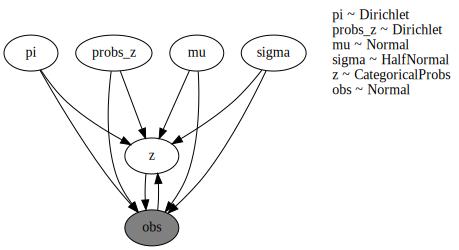

In [80]:
mc.create_sequences(df=df_train, feature_columns_list=features, pairs=pairs, window_size = 200)
mc.validate_model_structure()
mc.render_model()

In [81]:
mc.initialize_inference()
mc.run_model_inference()

100%|██████████| 15000/15000 [01:15<00:00, 199.29it/s, init loss: 555594.2500, avg. loss [14251-15000]: 19828.0527]


SVIRunResult(params={'mu_auto_loc': Array([[-1.0484719e+00, -5.1883590e-01,  1.0203726e-03,  3.6392704e-01,
        -1.0078226e+00],
       [-8.7446982e-01, -1.1976800e+00,  4.1875368e-01, -2.6749983e-01,
        -7.5454998e-01],
       [ 6.9054860e-01,  7.0909768e-01,  6.8652743e-01,  2.0289442e-02,
         7.3843133e-01]], dtype=float32), 'mu_auto_scale': Array([[0.02270025, 0.04312094, 0.01719126, 0.02752134, 0.01937666],
       [0.00890259, 0.02080546, 0.00154188, 0.00924082, 0.00778643],
       [0.00238145, 0.00330893, 0.0103561 , 0.0047048 , 0.00257689]],      dtype=float32), 'pi_auto_loc': Array([-0.24300514, -0.0281693 ], dtype=float32), 'pi_auto_scale': Array([1.4275553, 1.7323784], dtype=float32), 'probs_z_auto_loc': Array([[-2.7911925, -4.5888114],
       [-2.791993 , -4.5882287],
       [-2.7913787, -4.586643 ]], dtype=float32), 'probs_z_auto_scale': Array([[0.05262965, 0.08184487],
       [0.05174112, 0.08149039],
       [0.05003332, 0.08229975]], dtype=float32), 'sigma_a

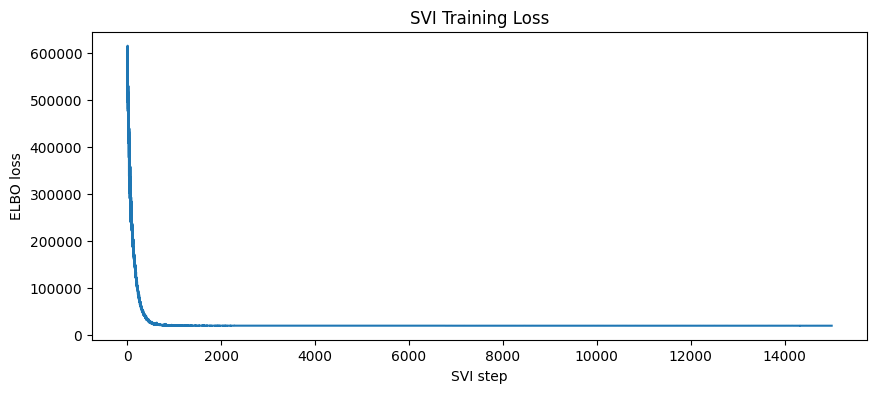

State 0: 3.09%
State 1: 1.00%
State 2: 95.91%
Transition matrix (rows sum to 1):
[[0.02790845 0.0094686  0.962623  ]
 [0.02810882 0.01050371 0.96138746]
 [0.02853587 0.01007697 0.96138716]]


In [82]:
pc = PeekParams(mc)
pc.plot_training_loss()
pc.get_state_percentage()
pc.get_transition_matrix()